# BA Lounge Eligibility Model

This notebook estimates how many passengers on each British Airways flight would be eligible for each of the three Terminal 3 lounge tiers (Concorde Room, First Lounge, Club Lounge), based on a set of broad, reusable flight categories rather than exact flight numbers or aircraft types.

The approach: group flights by haul length, arrival region, and peak/off-peak departure time (8 categories total), apply assumed eligibility percentages per category, then apply that model to the full 10,000-flight summer schedule and validate the estimates against the dataset's actual eligibility figures.

## Load libraries
Import pandas for data handling and matplotlib for charts.

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

## Load the data
Load the BA summer flight schedule (10,000 flights) into a DataFrame and preview the first few rows.

In [3]:
df = pd.read_excel("British Airways_Summer_Schedule.x")
df.head()

,FLIGHT_DATE,FLIGHT_TIME,TIME_OF_DAY,AIRLINE_CD,FLIGHT_NO,DEPARTURE_STATION_CD,ARRIVAL_STATION_CD,ARRIVAL_COUNTRY,ARRIVAL_REGION,HAUL,AIRCRAFT_TYPE,FIRST_CLASS_SEATS,BUSINESS_CLASS_SEATS,ECONOMY_SEATS,TIER1_ELIGIBLE_PAX,TIER2_ELIGIBLE_PAX,TIER3_ELIGIBLE_PAX
0,2025-09-02,14:19:00,Afternoon,BA,BA5211,LHR,LAX,USA,North America,LONG,B777,8,49,178,0,10,38
1,2025-06-10,06:42:00,Morning,BA,BA7282,LHR,LAX,USA,North America,LONG,B777,8,49,178,0,7,28
2,2025-10-27,15:33:00,Afternoon,BA,BA1896,LHR,FRA,Germany,Europe,SHORT,A320,0,17,163,0,11,40
3,2025-06-15,18:29:00,Evening,BA,BA5497,LHR,IST,Turkey,Europe,SHORT,A320,0,8,172,0,16,54
4,2025-08-25,20:35:00,Evening,BA,BA1493,LHR,FRA,Germany,Europe,SHORT,A320,0,13,167,0,6,27


List every column in the dataset so we know what fields are available to work with.

In [4]:
df.columns.tolist()

['FLIGHT_DATE',
 'FLIGHT_TIME',
 'TIME_OF_DAY',
 'AIRLINE_CD',
 'FLIGHT_NO',
 'DEPARTURE_STATION_CD',
 'ARRIVAL_STATION_CD',
 'ARRIVAL_COUNTRY',
 'ARRIVAL_REGION',
 'HAUL',
 'AIRCRAFT_TYPE',
 'FIRST_CLASS_SEATS',
 'BUSINESS_CLASS_SEATS',
 'ECONOMY_SEATS',
 'TIER1_ELIGIBLE_PAX',
 'TIER2_ELIGIBLE_PAX',
 'TIER3_ELIGIBLE_PAX']

## Build helper columns
Create `TOTAL_SEATS` (First + Business + Economy seats added together) and `PEAK_OFFPEAK` (Morning/Evening flights labelled Peak, everything else Off-peak).

In [14]:
df["TOTAL_SEATS"] = df['FIRST_CLASS_SEATS'] + df['BUSINESS_CLASS_SEATS'] + df['ECONOMY_SEATS']
df["PEAK_OFFPEAK"] = df["TIME_OF_DAY"].apply(lambda x:"Peak" if x in ["Morning","Evening"] else "Off-peak")
df[['TIME_OF_DAY', 'PEAK_OFFPEAK', 'TOTAL_SEATS']].head()

,TIME_OF_DAY,PEAK_OFFPEAK,TOTAL_SEATS
0,Afternoon,Off-peak,235
1,Morning,Peak,235
2,Afternoon,Off-peak,180
3,Evening,Peak,180
4,Evening,Peak,180


## Build the category column
Combine haul length, arrival region, and peak/off-peak into a single `CATEGORY` label per flight, then count how many flights fall into each of the 8 categories to confirm none are empty.

In [18]:
df["CATEGORY"] = df["HAUL"] + ", " + df["ARRIVAL_REGION"] + ", " + df["PEAK_OFFPEAK"] #category column that combines into one label
df["CATEGORY"].value_counts() #counts how many flights fall  into each category

CATEGORY
SHORT, Europe, Peak              3852
SHORT, Europe, Off-peak          2123
LONG, North America, Peak        1749
LONG, North America, Off-peak     909
LONG, Asia, Peak                  452
LONG, Middle East, Peak           450
LONG, Middle East, Off-peak       238
LONG, Asia, Off-peak              227
Name: count, dtype: int64

## Apply the lookup table
Define the assumed Tier 1/2/3 eligibility percentages for each of the 8 categories (based on the reasoning in the Forage submission: haul length and region as proxies for how business-heavy a route is, peak/off-peak time as a proxy for commuter vs leisure mix). Map every flight to its matching percentages based on its category.

In [28]:
lookup = {
    'SHORT, Europe, Peak':              {'T1': 0.005, 'T2': 0.05,  'T3': 0.20},
    'SHORT, Europe, Off-peak':          {'T1': 0.003, 'T2': 0.04,  'T3': 0.15},
    'LONG, North America, Peak':        {'T1': 0.003, 'T2': 0.03,  'T3': 0.12},
    'LONG, North America, Off-peak':    {'T1': 0.002, 'T2': 0.025, 'T3': 0.10},
    'LONG, Middle East, Peak':          {'T1': 0.003, 'T2': 0.03,  'T3': 0.12},
    'LONG, Middle East, Off-peak':      {'T1': 0.002, 'T2': 0.025, 'T3': 0.10},
    'LONG, Asia, Peak':                 {'T1': 0.003, 'T2': 0.03,  'T3': 0.11},
    'LONG, Asia, Off-peak':             {'T1': 0.002, 'T2': 0.025, 'T3': 0.09},
}
#all the rows get matched to its percentages

df['EST_T1_PCT'] = df['CATEGORY'].map(lambda x: lookup[x]['T1'])
df['EST_T2_PCT'] = df['CATEGORY'].map(lambda x: lookup[x]['T2'])
df['EST_T3_PCT'] = df['CATEGORY'].map(lambda x: lookup[x]['T3'])

df[['CATEGORY', 'EST_T1_PCT', 'EST_T2_PCT', 'EST_T3_PCT']].head()

,CATEGORY,EST_T1_PCT,EST_T2_PCT,EST_T3_PCT
0,"LONG, North America, Off-peak",0.002,0.025,0.10
1,"LONG, North America, Peak",0.003,0.030,0.12
2,"SHORT, Europe, Off-peak",0.003,0.040,0.15
3,"SHORT, Europe, Peak",0.005,0.050,0.20
4,"SHORT, Europe, Peak",0.005,0.050,0.20


## Convert percentages into estimated passenger counts
Multiply each flight's total seats by its percentage to get an estimated number of eligible passengers per tier, per flight.

In [29]:
# multiplies each flight's seat count by its percentage to get an estimated
# number of eligible passengers per tier, per flight.
df['EST_T1_PAX'] = df['TOTAL_SEATS'] * df['EST_T1_PCT']
df['EST_T2_PAX'] = df['TOTAL_SEATS'] * df['EST_T2_PCT']
df['EST_T3_PAX'] = df['TOTAL_SEATS'] * df['EST_T3_PCT']

df[['CATEGORY', 'TOTAL_SEATS', 'EST_T1_PAX', 'EST_T2_PAX', 'EST_T3_PAX']].head()

,CATEGORY,TOTAL_SEATS,EST_T1_PAX,EST_T2_PAX,EST_T3_PAX
0,"LONG, North America, Off-peak",235,0.470,5.875,23.5
1,"LONG, North America, Peak",235,0.705,7.050,28.2
2,"SHORT, Europe, Off-peak",180,0.540,7.200,27.0
3,"SHORT, Europe, Peak",180,0.900,9.000,36.0
4,"SHORT, Europe, Peak",180,0.900,9.000,36.0


## Total estimates by category
Group all 10,000 flights by category and sum the per-flight estimates, turning small per-flight fractions into real totals across the whole schedule.

In [32]:
summary = df.groupby('CATEGORY')[['EST_T1_PAX', 'EST_T2_PAX', 'EST_T3_PAX']].sum()
summary


,EST_T1_PAX,EST_T2_PAX,EST_T3_PAX
CATEGORY,,,
"LONG, Asia, Off-peak",132.098,1651.225,5944.41
"LONG, Asia, Peak",393.918,3939.180,14443.66
"LONG, Middle East, Off-peak",139.164,1739.550,6958.20
"LONG, Middle East, Peak",393.195,3931.950,15727.80
"LONG, North America, Off-peak",530.414,6630.175,26520.70
"LONG, North America, Peak",1534.080,15340.800,61363.20
"SHORT, Europe, Off-peak",1146.420,15285.600,57321.00
"SHORT, Europe, Peak",3466.800,34668.000,138672.00


## Per-flight averages
Add a flight count per category and divide the Tier 3 total by it, to see the average Tier 3 demand per single flight. This separates categories with high totals purely due to flight volume from categories that are genuinely more premium per flight.

In [33]:
summary['flight_count'] = df.groupby('CATEGORY').size()
summary['avg_T3_per_flight'] = summary['EST_T3_PAX'] / summary['flight_count']
summary

,EST_T1_PAX,EST_T2_PAX,EST_T3_PAX,flight_count,avg_T3_per_flight
CATEGORY,,,,,
"LONG, Asia, Off-peak",132.098,1651.225,5944.41,227,26.186828
"LONG, Asia, Peak",393.918,3939.180,14443.66,452,31.955000
"LONG, Middle East, Off-peak",139.164,1739.550,6958.20,238,29.236134
"LONG, Middle East, Peak",393.195,3931.950,15727.80,450,34.950667
"LONG, North America, Off-peak",530.414,6630.175,26520.70,909,29.175688
"LONG, North America, Peak",1534.080,15340.800,61363.20,1749,35.084734
"SHORT, Europe, Off-peak",1146.420,15285.600,57321.00,2123,27.000000
"SHORT, Europe, Peak",3466.800,34668.000,138672.00,3852,36.000000


## Chart 1: Total Tier 3 demand by category
Visualize total estimated Club Lounge demand across the schedule, by category.

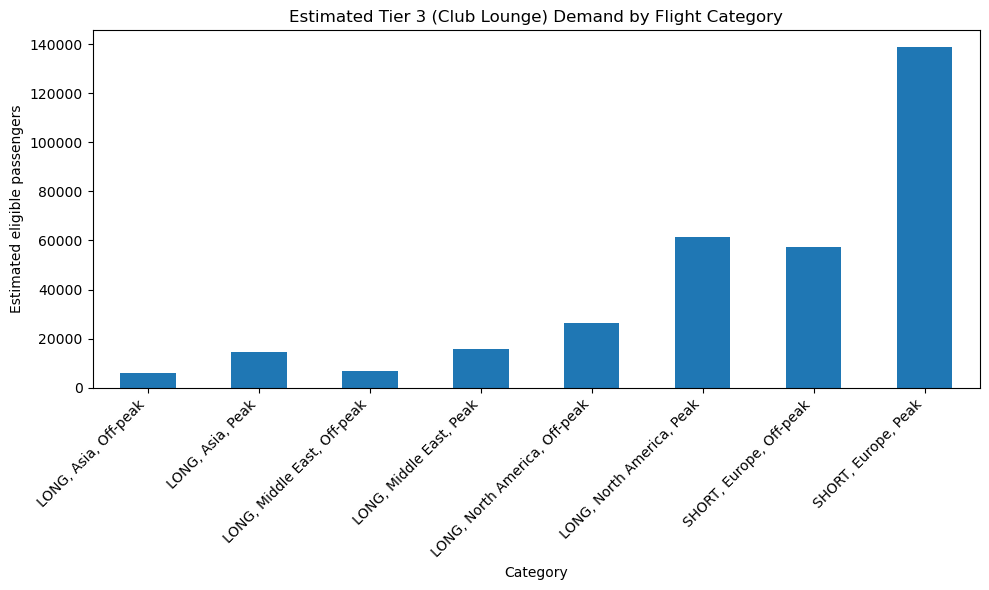

In [36]:
summary['EST_T3_PAX'].plot(kind='bar', figsize=(10,6))
plt.title('Estimated Tier 3 (Club Lounge) Demand by Flight Category')
plt.ylabel('Estimated eligible passengers')
plt.xlabel('Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Validate against actual eligibility data
Compare the estimated Tier 3 totals against the dataset's actual `TIER3_ELIGIBLE_PAX` figures, grouped by category, to check how close the assumptions landed against ground truth.

In [37]:
comparison = df.groupby('CATEGORY')[['EST_T3_PAX', 'TIER3_ELIGIBLE_PAX']].sum()
comparison

,EST_T3_PAX,TIER3_ELIGIBLE_PAX
CATEGORY,,
"LONG, Asia, Off-peak",5944.41,6977
"LONG, Asia, Peak",14443.66,13453
"LONG, Middle East, Off-peak",6958.20,7129
"LONG, Middle East, Peak",15727.80,13519
"LONG, North America, Off-peak",26520.70,27894
"LONG, North America, Peak",61363.20,54018
"SHORT, Europe, Off-peak",57321.00,64324
"SHORT, Europe, Peak",138672.00,116900


## Chart 2: Estimated vs actual
Plot estimated and actual Tier 3 eligible passengers side by side per category.

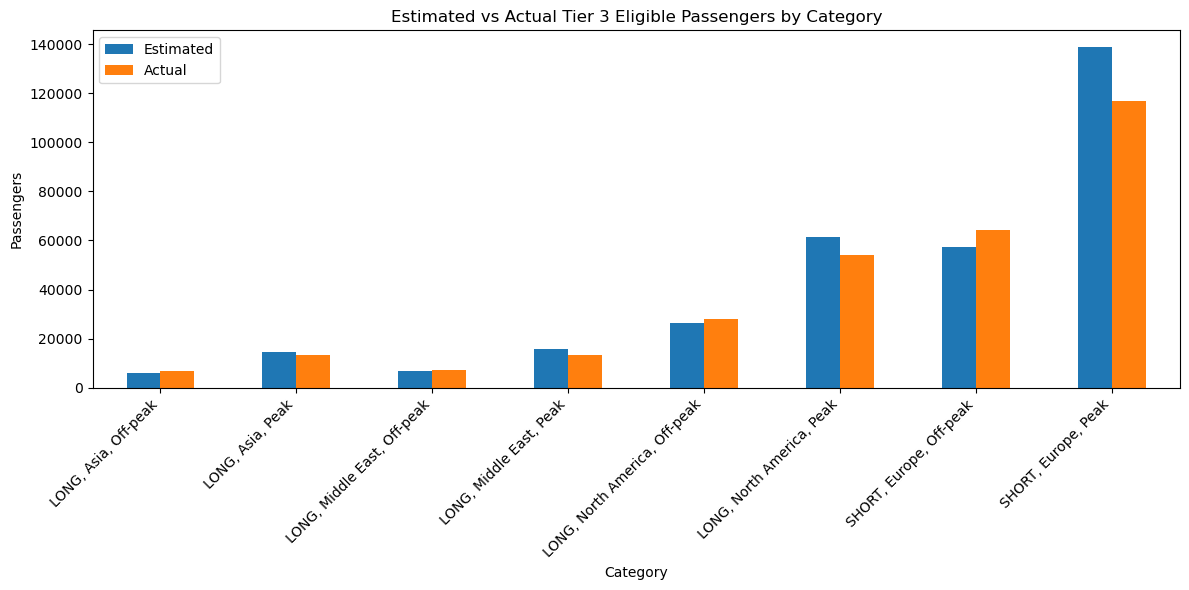

In [38]:
comparison.plot(kind='bar', figsize=(12,6))
plt.title('Estimated vs Actual Tier 3 Eligible Passengers by Category')
plt.ylabel('Passengers')
plt.xlabel('Category')
plt.xticks(rotation=45, ha='right')
plt.legend(['Estimated', 'Actual'])
plt.tight_layout()
plt.show()